<h1>Train — InceptionNet v3</h1>

Trains and evaluates InceptionNet v3 using the tuned hyperparameters from `ARCH_HYPERPARAMS["inception_v3"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1752 | Val: 495 | Test: 280


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["inception_v3"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"InceptionNet v3: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

InceptionNet v3: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with InceptionNet v3)
# ---------------------------------------------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)

in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

# The auxiliary classifier (used only during training, see run_epoch in
# wwtw_utils.py) also needs its output layer resized to our number of classes.
in_f_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(in_f_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[InceptionNet v3] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[InceptionNet v3] Epoch   1/100 | LR: 1.38e-03 | train loss 1.8471 acc 0.404 | val loss 0.8298 acc 0.572 *


[InceptionNet v3] Epoch   2/100 | LR: 1.38e-03 | train loss 1.3871 acc 0.540 | val loss 1.1174 acc 0.509


[InceptionNet v3] Epoch   3/100 | LR: 1.38e-03 | train loss 1.2896 acc 0.561 | val loss 0.8141 acc 0.671 *


[InceptionNet v3] Epoch   4/100 | LR: 1.38e-03 | train loss 1.1571 acc 0.638 | val loss 0.9030 acc 0.612


...

[InceptionNet v3] Epoch  39/100 | LR: 1.38e-04 | train loss 0.2480 acc 0.920 | val loss 0.4155 acc 0.875


[InceptionNet v3] Epoch  40/100 | LR: 1.38e-04 | train loss 0.2382 acc 0.928 | val loss 0.4368 acc 0.857


[InceptionNet v3] Epoch  41/100 | LR: 1.38e-04 | train loss 0.2444 acc 0.918 | val loss 0.4313 acc 0.873


[InceptionNet v3] Epoch  42/100 | LR: 1.38e-04 | train loss 0.2420 acc 0.926 | val loss 0.4297 acc 0.859


[InceptionNet v3] Epoch  43/100 | LR: 1.38e-04 | train loss 0.2015 acc 0.941 | val loss 0.4677 acc 0.879

[InceptionNet v3] No val loss improvement for 10 epochs — stopping early at epoch 43.

[InceptionNet v3] Restored best checkpoint (val loss = 0.4005)


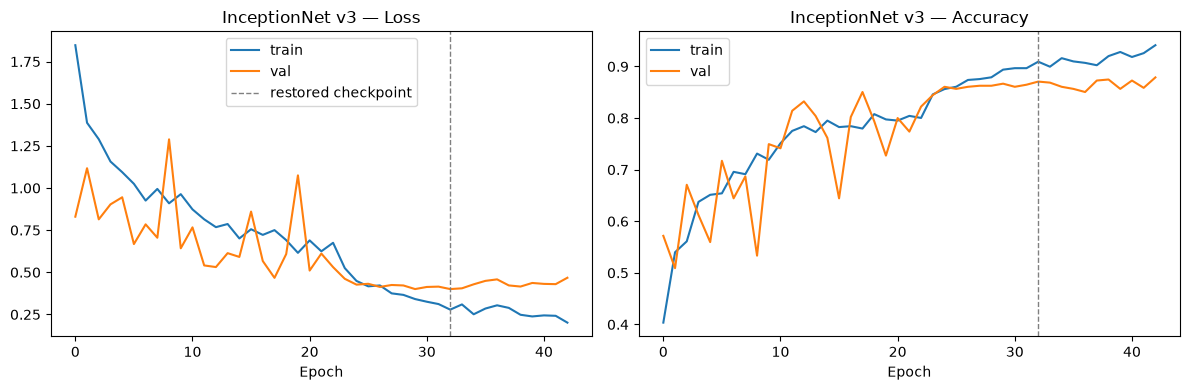

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "InceptionNet v3", is_inception=True,
    accum_steps=accum_steps,
)
plot_training_curves(history, "InceptionNet v3")

## Evaluate on the test set

[InceptionNet v3] Test accuracy: 0.868


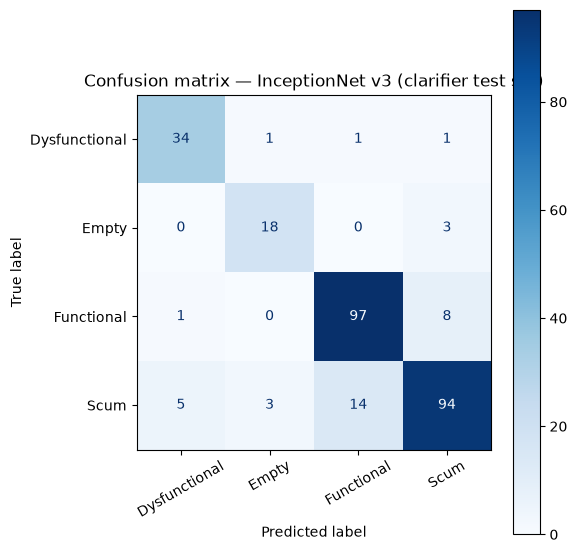

               precision    recall  f1-score   support

Dysfunctional      0.850     0.919     0.883        37
        Empty      0.818     0.857     0.837        21
   Functional      0.866     0.915     0.890       106
         Scum      0.887     0.810     0.847       116

     accuracy                          0.868       280
    macro avg      0.855     0.875     0.864       280
 weighted avg      0.869     0.868     0.867       280



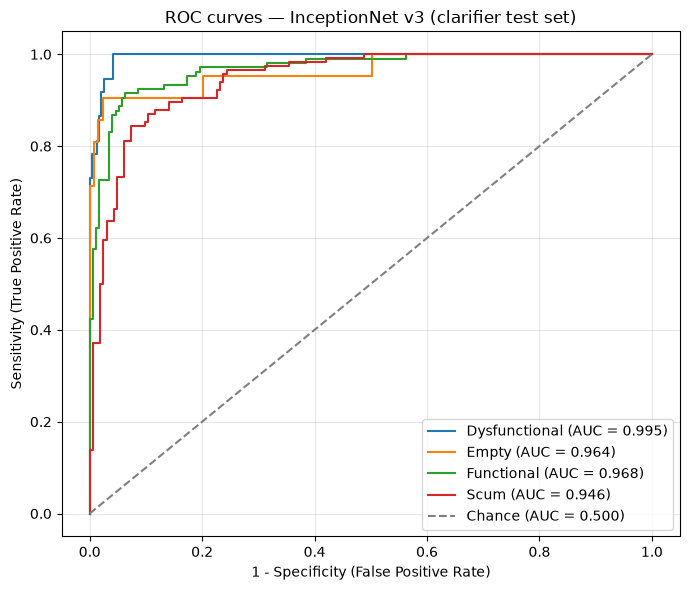

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.995
  Empty          : 0.964
  Functional     : 0.968
  Scum           : 0.946

Mean AUC (over 4/4 classes with test examples): 0.968


(np.float64(0.8678571428571429),
 {'Dysfunctional': 0.9945501056612167,
  'Empty': 0.9639639639639639,
  'Functional': 0.9682281500759055,
  'Scum': 0.9457527333894029})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "InceptionNet v3", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("InceptionNet v3", "inception_v3")

Saved results to ../results/clarifier_aug/results_clarifier_inception_v3_stratified.pkl
Saved model weights to ../models/clarifier_inception_v3_cnn.pt
